In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd

# train_path = "/content/drive/MyDrive/SNAIC-Wk1-Capstone/Kaggle_Data/train.csv" # Darren
# train_path = "/content/drive/MyDrive/train.csv" # KS
# train_path = "/content/train.csv" # joyce
train_path = "data/train.csv"  # local

df = pd.read_csv(train_path)

# fast-iter sample: set CAPSTONE_SAMPLE=N to downsample (0 = full data)
_n = int(os.environ.get("CAPSTONE_SAMPLE", "0"))
if _n:
    df = df.groupby("Churn", group_keys=False).sample(
        frac=min(1.0, _n / len(df)), random_state=42
    )

df.shape


(594194, 21)

In [ ]:
df.head()


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [ ]:
df.nunique()

,0
id,594194
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
      .sort_values("missing_count", ascending=False)
)

missing_summary


,missing_count,missing_pct
id,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Churn
No     460377
Yes    133817
Name: count, dtype: int64


/tmp/ipykernel_3292/2133494321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


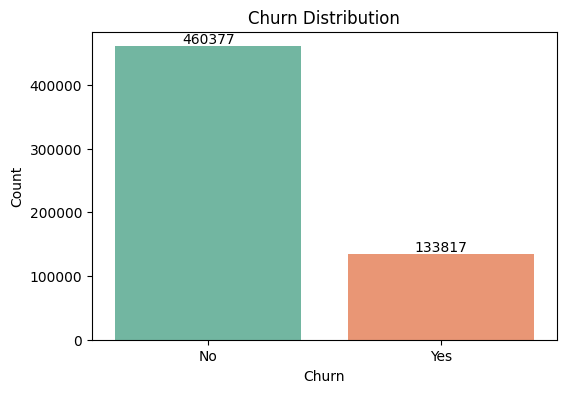

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count YES/NO values
churn_counts = df["Churn"].value_counts()
print(churn_counts)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", palette="Set2")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

# Show count labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

**1. Tenure vs Churn**

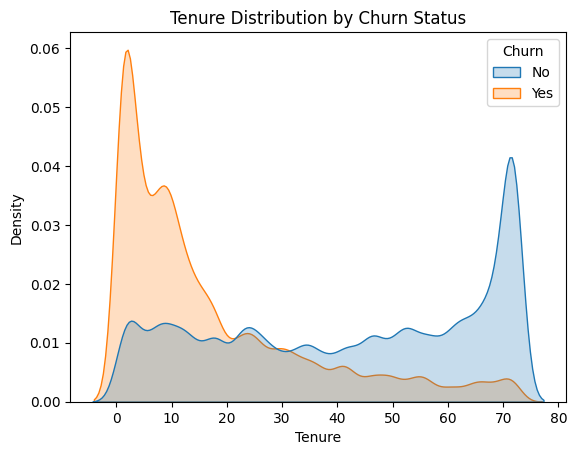

In [ ]:
# 1. Tenure Vs Churn
plt.figure()
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure')
plt.ylabel('Density')
plt.show()
# Insight: New customers (low tenure) have the highest churn risk. Loyalty builds over time.

**2. MonthlyCharges vs Churn**

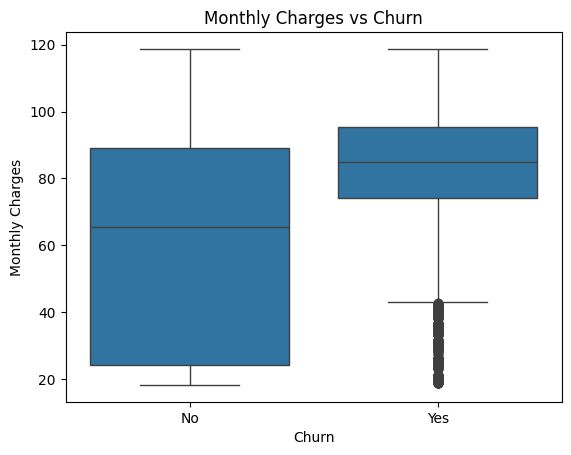

In [ ]:
# 2. MonthlyCharges vs Churn
plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()
# Insight: Higher monthly charges correlate with higher churn probability (pricing sensitivity).

**3. Contract vs Churn**

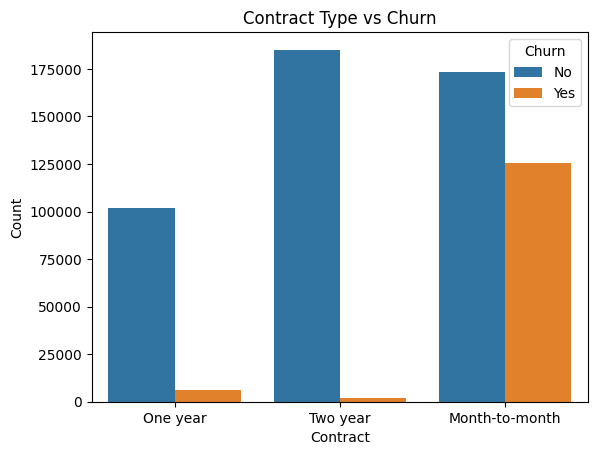

In [ ]:
#3. Contract vs Churn
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.show()

In [ ]:
rows_with_missing = df.isna().any(axis=1).sum()
total_missing_values = df.isna().sum().sum()

print(f"Rows with missing values: {rows_with_missing:,}")
print(f"Total missing values: {total_missing_values:,}")


Rows with missing values: 0
Total missing values: 0


In [ ]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [ ]:
X = df.drop(columns=["id", "Churn"])
y = df["Churn"]

print(X.shape)
print(y.shape)

(594194, 19)
(594194,)


# Train TEST SPLIT for BaseLine : Random Forest

In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, len(y_train))
print("Validation:", X_val.shape, len(y_val))
print("Test:", X_test.shape, len(y_test))

Train: (415935, 19) 415935
Validation: (89129, 19) 89129
Test: (89130, 19) 89130


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

categorical_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection",	"TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

preprocessor = ColumnTransformer([
    # ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols),
])

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
baseline_model.get_feature_names_out

<bound method Pipeline.get_feature_names_out of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier', RandomForestClassifier(random_state=42))])>

In [ ]:
# Extract feature names and importances
feature_names = baseline_model.named_steps['preprocessor'].get_feature_names_out()
importances = baseline_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame(
    {
        'Feature': feature_names,
        'Importance': importances
    }
).sort_values(by='Importance', ascending=False)

print(importance_df)

                                         Feature  Importance
44                             num__TotalCharges    0.226653
43                           num__MonthlyCharges    0.193382
42                                   num__tenure    0.150846
39           cat__PaymentMethod_Electronic check    0.063189
32                  cat__Contract_Month-to-month    0.047081
12              cat__InternetService_Fiber optic    0.041211
14                        cat__OnlineSecurity_No    0.038519
23                           cat__TechSupport_No    0.026379
34                        cat__Contract_Two year    0.016929
11                      cat__InternetService_DSL    0.012264
17                          cat__OnlineBackup_No    0.011827
41                            num__SeniorCitizen    0.011814
36                     cat__PaperlessBilling_Yes    0.007997
0                             cat__gender_Female    0.007976
1                               cat__gender_Male    0.007927
20                      

Train accuracy: 0.9999471071201029
Test accuracy: 0.8430606978570627
Validation accuracy: 0.8389974082509621
Confusion Matrix:
[[63213  5844]
 [ 8144 11929]]


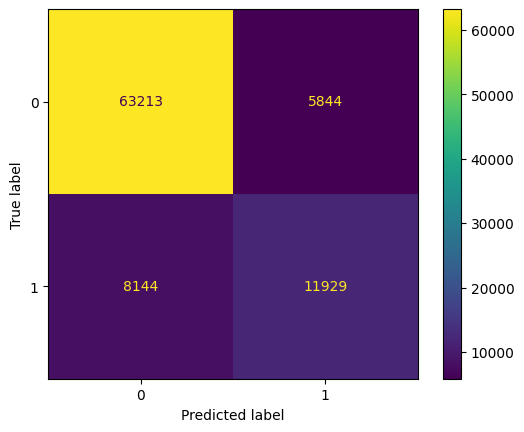

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_pred = baseline_model.predict(X_train)
test_pred = baseline_model.predict(X_test)
val_pred = baseline_model.predict(X_val)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
val_accuracy = accuracy_score(y_val, val_pred)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
print("Validation accuracy:", val_accuracy)

# Assuming y_test is the true labels and y_pred are the predictions
conf_matrix = confusion_matrix(y_test, test_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Create a ConfusionMatrixDisplay instance
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=baseline_model.named_steps['classifier'].classes_)

# Plot the confusion matrix
display.plot()
plt.show()

In [ ]:
import joblib

file_name = "/content/drive/MyDrive/Colab_Notebooks/Wk1_capstone/models/model_randomforest_default.joblib"

try:
    joblib.dump(model, file_name)
    print(f"Model exported successfully as: {file_name}")
except Exception as e:
    print(f"Error saving model: {e}")

Model exported successfully as: /content/drive/MyDrive/Colab_Notebooks/Wk1_capstone/models/model_randomforest_default.joblib


# Model Comparison


*   Train TEst split for Model comparsionL
*  80% Train 20% Test




In [ ]:
from sklearn.model_selection import train_test_split

# 1.5 Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution (count):")
print(y_train.value_counts().sort_index())

print("\nTraining target distribution (proportion):")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution (count):")
print(y_test.value_counts().sort_index())

# print("\nTest target distribution (proportion):")
# print(y_test.value_counts(normalize=True).sort_index())
# split_summary = pd.DataFrame({
#     "Class": [0, 1, 2],
#     "Train Count": y_train.value_counts().sort_index().values,
#     "Train Proportion": (y_train.value_counts(normalize=True).sort_index().values * 100).round(2),
#     "Test Count": y_test.value_counts().sort_index().values,
#     "Test Proportion": (y_test.value_counts(normalize=True).sort_index().values * 100).round(2),
# })

# split_summary["Train Proportion"] = split_summary["Train Proportion"].astype(str) + "%"
# split_summary["Test Proportion"] = split_summary["Test Proportion"].astype(str) + "%"

# split_summary

X_train shape: (475355, 19)
X_test shape: (118839, 19)
y_train shape: (475355,)
y_test shape: (118839,)

Training target distribution (count):
Churn
0    368301
1    107054
Name: count, dtype: int64

Training target distribution (proportion):
Churn
0    0.774791
1    0.225209
Name: proportion, dtype: float64

Test target distribution (count):
Churn
0    92076
1    26763
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=100,random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
    )
}

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectPercentile, chi2
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(
    steps=[("scaler", MinMaxScaler())]
)

# Categorical transformer: One-Hot Encoding followed by Chi-Square selection
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore")),  # dense output needed for chi2
        ("selector", SelectPercentile(score_func=chi2, percentile=50))
    ]
)

# Full preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
from imblearn.pipeline import Pipeline as imPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,average_precision_score,
                             recall_score, f1_score, confusion_matrix,balanced_accuracy_score,
                             ConfusionMatrixDisplay, classification_report, roc_curve,make_scorer)

from sklearn.model_selection import cross_val_score


results = {}
conf_matrices = {}

for name, model in classifiers.items():

    clf = imPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("classifier", model),
        ]
    )

    # Train
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm

    # Metrics
    results[name] = {
        # "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print(results[name])


Logistic Regression
Confusion Matrix:
[[71789 20287]
 [ 3117 23646]]
{'Balanced Accuracy': np.float64(0.8316021887077205), 'ROC AUC': np.float64(0.8316021887077206), 'Precision': 0.5382286663783489, 'Recall': 0.8835332361842843, 'F1': 0.6689487382595903}

Random Forest
Confusion Matrix:
[[79293 12783]
 [ 7822 18941]]
{'Balanced Accuracy': np.float64(0.784449928340049), 'ROC AUC': np.float64(0.7844499283400491), 'Precision': 0.5970558567645946, 'Recall': 0.7077308224040653, 'F1': 0.6476994887752834}

XGBoost
Confusion Matrix:
[[75075 17001]
 [ 3777 22986]]
{'Balanced Accuracy': np.float64(0.837115687474541), 'ROC AUC': np.float64(0.837115687474541), 'Precision': 0.5748368219671394, 'Recall': 0.8588723237305235, 'F1': 0.6887191011235955}


# HyperParameter Tuning

In [ ]:
log_pipeline = imPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=100)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=100))
])

param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__class_weight': ['balanced']
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=log_pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='recall',  # Evaluation metric
    n_jobs=-1,  # Utilize all available cores
    verbose=1
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [ ]:
print("Best parameters:", grid_search.best_params_)

In [ ]:
print("Best parameters for Logistic Regression:", grid_search.best_params_)
print("Best accuracy for Logistic Regression:", grid_search.best_score_)
best_lr_model = grid_search.best_estimator_

In [ ]:
y_test_pred_lr = best_lr_model.predict(X_test)

y_test_proba_lr = best_lr_model.predict_proba(X_test)[:, 1]

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_lr)
print("Confusion Matrix:\n", cm)

In [ ]:
# Metrics
bal_acc = balanced_accuracy_score(y_test, y_test_pred_lr)
roc_auc = roc_auc_score(y_test, y_test_proba_lr)
precision = precision_score(y_test, y_test_pred_lr)
recall = recall_score(y_test, y_test_pred_lr)
f1 = f1_score(y_test, y_test_pred_lr)

In [ ]:
print("\nMetrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")